In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = "/content/drive/MyDrive/kg_recsys"
os.makedirs(os.path.join(PROJECT_ROOT, "cache"), exist_ok=True)

import subprocess
subprocess.run(["pip", "install", "-q", "transformers", "tqdm"], check=True)

Mounted at /content/drive


CompletedProcess(args=['pip', 'install', '-q', 'transformers', 'tqdm'], returncode=0)

In [2]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm import tqdm
import torch

# Add scripts folder to path
SCRIPTS_DIR = os.path.join(PROJECT_ROOT, "scripts")
sys.path.insert(0, SCRIPTS_DIR)
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from data_prep import load_ml100k, load_ml1m, subset_data, train_test_split, GENRE_COLS
from kg_builder import build_adj, load_or_build_kg, BASE_RELS, load_or_build_kg_imdb
from paths import sample_guided_paths, path_is_faithful
from model import (
    build_vocab, is_relation, create_path_dataset, create_model,
    train_model, score_path, generate_topk, enumerate_candidates,
)
from metrics import (
    evaluate_ranking, compute_group_metrics,
    compute_all_ilap_metrics, print_ilap_report,
    demographic_parity, counterfactual_fairness_score,
    print_additional_fairness_report, build_user_gender_map,
    path_diversity_summary, print_path_diversity_report,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [3]:
LAMBDA_PATH_BALANCE = 0.0
PATH_BALANCE_FREE_REPEATS = 2

EVAL_BATCH_SIZE = 2048 if torch.cuda.is_available() else 256
print("Evaluation batch size:", EVAL_BATCH_SIZE)

MAX_PATHS_PER_MOVIE = 5
print("Max paths per movie:", MAX_PATHS_PER_MOVIE)

Evaluation batch size: 2048
Max paths per movie: 5


In [4]:
DATASET_NAME = "ML-1M"
DATA_DIR = os.path.join(PROJECT_ROOT, "ml-1m")
LIKE_THRESHOLD = 4
MAX_USERS = 1000
MAX_MOVIES = 1000
BALANCE_GENDER = True

# Load MovieLens-1M dataset
ratings, movies, users = load_ml1m(DATA_DIR)

# Select a reproducible subset and convert ratings >= LIKE_THRESHOLD to implicit positives
ratings_sub, movies_sub, users_sub, positive_interactions, user_info = subset_data(
    ratings,
    movies,
    users,
    max_users=MAX_USERS,
    max_movies=MAX_MOVIES,
    like_threshold=LIKE_THRESHOLD,
    balance_gender=BALANCE_GENDER,
)

print(f"Users in subset: {len(users_sub)}")
print(f"Movies in subset: {len(movies_sub)}")
print(f"Ratings in subset: {len(ratings_sub)}")
print(f"Positive interactions rating >= {LIKE_THRESHOLD}: {len(positive_interactions)}")
print("Gender distribution:")
print(users_sub["gender"].value_counts())


Loaded ML-1M -> Ratings: (1000209, 4), Movies: (3883, 21), Users: (6040, 5)
Gender distribution: {'M': 4331, 'F': 1709}
Subset -> Users: 1000, Movies: 1000, Positive interactions: 199237
Gender split: {'F': 500, 'M': 500}
ML-1M DATASET FOR -STYLE COMPARISON
Users in subset: 1000
Movies in subset: 1000
Ratings in subset: 320376
Positive interactions rating >= 4: 199237
Gender distribution:
gender
F    500
M    500
Name: count, dtype: int64


In [5]:
IMDB_DIR = os.path.join(PROJECT_ROOT, "data", "imdb")
KG_CACHE_PATH = os.path.join(PROJECT_ROOT, "cache", f"kg_cache_imdb_{DATASET_NAME.lower()}_{MAX_USERS}u_{MAX_MOVIES}m.pkl")

print("Loading/Building Knowledge Graph from IMDb")

tconst_map, label_cache, kg_triples, readable_triples, movies_sub = load_or_build_kg_imdb(
    movies_sub,
    imdb_dir=IMDB_DIR,
    cache_path=KG_CACHE_PATH,
    max_cast=5,
)

SEP = "=" * 80
print(f"{SEP}")
print("Knowledge Graph Statistics")
print(f"{SEP}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Movies in selected MovieLens subset: {len(movies)}")
print(f"  Movies matched with IMDb: {len(movies_sub)}")
print(f"  Readable triples: {len(readable_triples)}")

from collections import Counter
rel_counts = Counter(r for _, r, _ in readable_triples)

print(f"{SEP}")
print("Top relations:")
for rel, cnt in rel_counts.most_common(10):
    print(f"  {rel:20s}: {cnt:5d}")
print(f"{SEP}")


Loading/Building Knowledge Graph from IMDb
Loading KG from cache: /content/drive/MyDrive/kg_recsys/cache/kg_cache_imdb_ml-1m_1000u_1000m.pkl
  Cache fully covers requested 1000 movies.
  movies with tconst: 718, readable_triples: 11670
Knowledge Graph Statistics
  Dataset: ML-1M
  Movies in selected MovieLens subset: 3883
  Movies matched with IMDb: 718
  Readable triples: 11670
Top relations:
  hasCast             :  3442
  writtenBy           :  1982
  hasGenre            :  1838
  hasProducer         :  1164
  year                :  1000
  directedBy          :   829
  hasCinematographer  :   721
  hasComposer         :   694


In [6]:
movies_before_filter = movies_sub.copy()

movie_titles_in_kg = {
    h for h, r, t in readable_triples
    if h in set(movies_sub["title"])
}

movies_sub = movies_sub[
    movies_sub["title"].isin(movie_titles_in_kg)
].copy()

matched_movie_ids = set(movies_sub["movieId"].astype(int))

positive_interactions = positive_interactions[
    positive_interactions["movieId"].isin(matched_movie_ids)
].copy()

ratings_sub = ratings_sub[
    ratings_sub["movieId"].isin(matched_movie_ids)
].copy()

print(f"Movies after KG filtering: {len(movies_sub)} (was {len(movies_before_filter)})")
print(f"Positive interactions after KG filtering: {len(positive_interactions)}")
print(f"Ratings after KG filtering: {len(ratings_sub)}")

Movies after KG filtering: 718 (was 718)
Positive interactions after KG filtering: 144147
Ratings after KG filtering: 234259


In [7]:
from collections import Counter, defaultdict

rel_counts = Counter(r for _, r, _ in readable_triples)
total_triples = len(readable_triples)

movie_titles = set(movies_sub["title"])

rel_movie_coverage = defaultdict(set)

for h, r, t in readable_triples:
    if h in movie_titles:
        rel_movie_coverage[r].add(h)

print(f"KG Coverage Report ({total_triples} total readable triples)")
print(f"  Movies in KG: {len(movies_sub)}")
print(f"  Avg triples/movie: {total_triples / max(len(movies_sub), 1):.1f}")
print()

print(f'{"Relation":<20} {"Triples":>8} {"Movies":>8} {"Coverage %":>12}')
print("-" * 54)

for rel, cnt in rel_counts.most_common():
    if rel.startswith("rev_"):
        continue

    movie_count = len(rel_movie_coverage.get(rel, set()))
    coverage = movie_count / max(len(movies_sub), 1) * 100

    print(f"{rel:<20} {cnt:>8} {movie_count:>8} {coverage:>11.1f}%")

print()

covered_titles = {
    h for h, r, t in readable_triples
    if h in movie_titles
}

uncovered = len(movies_sub) - len(covered_titles)

print(
    f"Movies with 0 KG triples: {uncovered} "
    f"({uncovered / max(len(movies_sub), 1):.1%})"
)

KG Coverage Report (11670 total readable triples)
  Movies in KG: 718
  Avg triples/movie: 16.3

Relation              Triples   Movies   Coverage %
------------------------------------------------------
hasCast                  3442      711        99.0%
writtenBy                1982      711        99.0%
hasGenre                 1838      718       100.0%
hasProducer              1164      674        93.9%
year                     1000      718       100.0%
directedBy                829      717        99.9%
hasCinematographer        721      691        96.2%
hasComposer               694      640        89.1%

Movies with 0 KG triples: 0 (0.0%)


In [8]:
train_interactions, test_interactions, user_item_edges, test_set_dict = train_test_split(
    positive_interactions, movies_sub, test_ratio=0.2,
    kg_movie_titles=movie_titles_in_kg
)

Total (after user filter): 144147
Train: 114930 (79.7%)
Test:  29217 (20.3%)
Avg test items per user: 29.2

Train edges: 114930
Test users:  1000
Test pairs:  29217
Test pairs filtered (not in KG): 0


In [9]:
adj = build_adj(readable_triples, user_item_edges, user_info)
movie_titles_set = set(movies_sub["title"])
print(f"Movie titles in KG: {len(movie_titles_set)}")

Adj → nodes: 6918, total edge-instances: 255200
  rev_hasCast: 2104
  rev_writtenBy: 1392
  likes: 1000
  hasGender: 1000
  year: 1000
  rev_hasProducer: 731
  rev_likes: 718
  hasGenre: 718
  directedBy: 717
  writtenBy: 711
  hasCast: 711
  hasCinematographer: 691
  hasProducer: 674
  hasComposer: 640
  rev_directedBy: 462
  rev_hasCinematographer: 338
  rev_hasComposer: 291
  rev_year: 74
  rev_hasGenre: 22
  rev_hasGender: 2
Movie titles in KG: 718


In [10]:
import random

all_users = sorted({u for u, r, t in user_item_edges if r == "likes"})
print(f"Training users: {len(all_users)}")

PATHS_PER_USER_M = 300
PATHS_PER_USER_F = 300

PATTERN_WEIGHTS = {
    "genre":    0.25,
    "director": 0.20,
    "cf":       0.25,
    "cast":     0.15,
    "writer":   0.15,
}

male_users = []
female_users = []

for u in all_users:
    uid = int(u.replace("User_", ""))
    g = user_info.get(uid, {}).get("gender")
    if g == "M":
        male_users.append(u)
    elif g == "F":
        female_users.append(u)

print("Male training users:", len(male_users))
print("Female training users:", len(female_users))

paths_male = sample_guided_paths(
    users=male_users,
    adj=adj,
    paths_per_user=PATHS_PER_USER_M,
    pattern_weights=PATTERN_WEIGHTS,
)

paths_female = sample_guided_paths(
    users=female_users,
    adj=adj,
    paths_per_user=PATHS_PER_USER_F,
    pattern_weights=PATTERN_WEIGHTS,
)

paths = paths_male + paths_female
random.shuffle(paths)

print(f"Total paths: {len(paths)}")
print(f"Male paths: {len(paths_male)}")
print(f"Female paths: {len(paths_female)}")

faithful = sum(path_is_faithful(p, adj) for p in paths) / max(1, len(paths))
print(f"Faithful paths: {faithful:.1%}")

print("\nSample paths:")
for p in paths[:3]:
    print("  ", " -> ".join(str(x) for x in p))


Training users: 1000
Male training users: 500
Female training users: 500
Pattern distribution:
  genre: 65278 (43.5%)
  director: 22144 (14.8%)
  cf: 37362 (24.9%)
  cast: 13344 (8.9%)
  writer: 11872 (7.9%)
Total paths before dedupe: 150000
After dedupe: 146247
Pattern distribution:
  genre: 65968 (44.0%)
  director: 21709 (14.5%)
  cf: 37735 (25.2%)
  cast: 13244 (8.8%)
  writer: 11344 (7.6%)
Total paths before dedupe: 150000
After dedupe: 144146
Total paths: 290393
Male paths: 146247
Female paths: 144146
Faithful paths: 100.0%

Sample paths:
   User_1794 -> likes -> Schindler's List (1993) -> hasCast -> Ralph Fiennes -> rev_hasCast -> Quiz Show (1994)
   User_931 -> likes -> Aladdin (1992) -> hasGenre -> Adventure -> rev_hasGenre -> On Her Majesty's Secret Service (1969)
   User_1683 -> likes -> Sixteen Candles (1984) -> hasGenre -> Comedy -> rev_hasGenre -> Beavis and Butt-head Do America (1996)


In [11]:
vocab, id2tok, PAD, BOS, EOS, UNK = build_vocab(paths, BASE_RELS)
print(f"Vocab size: {len(vocab)}")

train_loader, val_loader, MAX_LEN, all_entities = create_path_dataset(
    paths, vocab, BASE_RELS, PAD, BOS, EOS, UNK,
    batch_size=(256 if torch.cuda.is_available() else 64), val_ratio=0.1,
)


Vocab size: 2792
MAX_LEN: 9
Train paths: 261353, Val paths: 29040
Train batches: 1021, Val batches: 114


In [12]:
MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, "cache", "gpt2_kg_model.pt")

model = create_model(
    vocab_size=len(vocab),
    max_len=MAX_LEN,
    BOS=BOS,
    EOS=EOS,
    device=device,
    n_embd=256,
    n_layer=6,
    n_head=8,
    dropout=0.1,
)

# Build gender labels for adversarial training
user_gender_labels = {}
for uid, info in user_info.items():
    token = f"User_{int(uid)}"
    g = info.get("gender", "")
    if g == "M": user_gender_labels[token] = 1
    elif g == "F": user_gender_labels[token] = 0
print(f"Gender labels: {sum(v==1 for v in user_gender_labels.values())}M, {sum(v==0 for v in user_gender_labels.values())}F")

model = train_model(
    model,
    train_loader,
    val_loader,
    device=device,
    epochs=15,
    lr=3e-4,
    patience=3,
    user_gender_labels=user_gender_labels,
    vocab=vocab,
    lambda_adv=0.1,
    adv_warmup_epochs=2,  # more epochs, GPU handles it
)

# Save model checkpoint
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "id2tok": id2tok,
    "MAX_LEN": MAX_LEN,
    "PAD": PAD, "BOS": BOS, "EOS": EOS, "UNK": UNK,
}, MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")


Model params: 5,456,128
Gender labels: 500M, 500F
Adversarial training enabled (λ=0.1, warmup=2)


Epoch 1/15: 100%|██████████| 1021/1021 [00:43<00:00, 23.58it/s, loss=2.7472, lr=2.97e-04]


  Epoch 1 val_loss: 2.7734


Epoch 2/15: 100%|██████████| 1021/1021 [00:42<00:00, 24.23it/s, loss=2.6549, lr=2.87e-04]


  Epoch 2 val_loss: 2.6290


...

  Epoch 13 val_loss: 2.4844


Epoch 14/15: 100%|██████████| 1021/1021 [00:57<00:00, 17.89it/s, loss=2.7514, lr=1.32e-05]


  Epoch 14 val_loss: 2.4835


Epoch 15/15: 100%|██████████| 1021/1021 [00:56<00:00, 18.04it/s, loss=2.6429, lr=1.00e-05]


  Epoch 15 val_loss: 2.4830
Restored best model (val_loss: 2.4830)
Model saved to /content/drive/MyDrive/kg_recsys/cache/gpt2_kg_model.pt


In [13]:
# ── Optional: Load saved model (skip training) ──────────────────
# Uncomment to restore a previously saved model instead of retraining.
#
# checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
# model = create_model(vocab_size=len(vocab), max_len=MAX_LEN,
#     BOS=BOS, EOS=EOS, device=device, n_embd=192, n_layer=4, n_head=4)
# model.load_state_dict(checkpoint["model_state_dict"])
# model = model.to(device)
# print("Model loaded from", MODEL_SAVE_PATH)

In [14]:
sample_user = list(test_set_dict.keys())[0]
topk = generate_topk(
    sample_user, model, vocab, id2tok, adj, BASE_RELS,
    movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
    device=device, K=5, lambda_div=LAMBDA_PATH_BALANCE,
    path_balance_free_repeats=PATH_BALANCE_FREE_REPEATS,
    eval_batch_size=EVAL_BATCH_SIZE,
    max_paths_per_movie=MAX_PATHS_PER_MOVIE,
)

print(f"Recommendations for {sample_user}:")
for movie, pat_type, _ in topk:
    print(f"  [{pat_type:>10}]  {movie}")

Recommendations for User_10:
  [    writer]  Star Wars: Episode V - The Empire Strikes Back (1980)
  [  director]  Star Wars: Episode IV - A New Hope (1977)
  [      cast]  American Beauty (1999)
  [      cast]  Schindler's List (1993)
  [      cast]  Fargo (1996)


In [15]:
def path_to_sentence(path_tokens):
    """Convert a path token list to a human-readable explanation."""
    if not path_tokens or len(path_tokens) < 3:
        return 'No explanation available.'
    rel_phrases = {
        'hasGenre':       'shares the genre',
        'directedBy':     'shares the director',
        'hasCast':        'shares cast members',
        'hasComposer':    'shares the composer',
        'writtenBy':      'shares the writer',
        'hasGender':      'was liked by a same-gender user who also liked',
        'rev_likes':      'was also liked by another user who liked',
    }
    try:
        if len(path_tokens) == 7:
            user, _, movie_a, rel, entity, _, movie_b = path_tokens
            phrase = rel_phrases.get(rel, f'is related via {rel} to')
            return (f'Recommended "{movie_b}" because you liked '
                    f'"{movie_a}", which {phrase} "{entity}".')
        return ' -> '.join(str(t) for t in path_tokens)
    except Exception:
        return ' -> '.join(str(t) for t in path_tokens)


In [16]:
K_VALUES = [10]
MAX_K = max(K_VALUES)

import pickle, os
CANDIDATES_CACHE_PATH = os.path.join(
    PROJECT_ROOT, "cache",
    f"candidates_{DATASET_NAME}_{MAX_USERS}u_{MAX_MOVIES}m.pkl"
)

if os.path.exists(CANDIDATES_CACHE_PATH):
    print("Loading candidates from cache...")
    with open(CANDIDATES_CACHE_PATH, "rb") as f:
        _cache = pickle.load(f)
    if isinstance(_cache, dict) and "candidates" in _cache:
        all_candidates_cache = _cache["candidates"]
        cf_overlap_cache     = _cache["cf_overlap"]
    else:
        all_candidates_cache = _cache
        cf_overlap_cache     = {}
        movie_to_users = {m: set(adj.get(m, {}).get("rev_likes", set())) for m in movie_titles_set}
        for user_node, candidates in tqdm(all_candidates_cache.items(), desc="CF overlap"):
            liked = set(adj[user_node].get("likes", set()))
            co_users_liked = {s: movie_to_users.get(s, set()) for s in liked}
            cf_overlap_cache[user_node] = {
                m: sum(len(movie_to_users.get(m, set()) & co_users_liked[s]) for s in liked)
                for m in candidates
            }
        with open(CANDIDATES_CACHE_PATH, "wb") as f:
            pickle.dump({"candidates": all_candidates_cache, "cf_overlap": cf_overlap_cache}, f)
    print(f"Loaded {len(all_candidates_cache)} users")
else:
    print(f"Pre-computing for {len(test_set_dict)} users...")
    all_candidates_cache = {}
    cf_overlap_cache     = {}
    movie_to_users = {m: set(adj.get(m, {}).get("rev_likes", set())) for m in movie_titles_set}
    for user_node in tqdm(test_set_dict.keys(), desc="Enumerating"):
        if user_node not in adj:
            continue
        liked = set(adj[user_node].get("likes", set()))
        candidates = enumerate_candidates(user_node, adj, movie_titles_set, liked,
                                          max_paths_per_movie=MAX_PATHS_PER_MOVIE)
        all_candidates_cache[user_node] = candidates
        co_users_liked = {s: movie_to_users.get(s, set()) for s in liked}
        cf_overlap_cache[user_node] = {
            m: sum(len(movie_to_users.get(m, set()) & co_users_liked[s]) for s in liked)
            for m in candidates
        }
    with open(CANDIDATES_CACHE_PATH, "wb") as f:
        pickle.dump({"candidates": all_candidates_cache, "cf_overlap": cf_overlap_cache}, f)
    print(f"Saved to {CANDIDATES_CACHE_PATH}")

results = []
print(f"Evaluating {len(test_set_dict)} users...")
for user_node, ground_truths in tqdm(test_set_dict.items(), desc="Evaluating"):
    if user_node not in adj:
        continue
    precomputed = all_candidates_cache.get(user_node)
    if precomputed is None:
        continue
    topk_with_type = generate_topk(
        user_node, model, vocab, id2tok, adj, BASE_RELS,
        movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
        device=device, K=MAX_K,
        lambda_div=LAMBDA_PATH_BALANCE,
        path_balance_free_repeats=PATH_BALANCE_FREE_REPEATS,
        eval_batch_size=EVAL_BATCH_SIZE,
        max_paths_per_movie=MAX_PATHS_PER_MOVIE,
        _precomputed_candidates=precomputed,
        _precomputed_cf=cf_overlap_cache.get(user_node),
    )
    if not topk_with_type:
        continue
    results.append({
        "user":          user_node,
        "ground_truths": ground_truths,
        "top_k_recs":    [c for c, t, p in topk_with_type],
        "pattern_types": [t for c, t, p in topk_with_type],
        "paths":         [p for c, t, p in topk_with_type],
        "num_gt":        len(ground_truths),
    })
print(f"Evaluated {len(results)} users")


Loading candidates from cache...
Loaded 1000 users
Evaluating 1000 users...


Evaluating: 100%|██████████| 1000/1000 [05:11<00:00,  3.21it/s]

Evaluated 1000 users


In [17]:
print('=== Example Recommendations with Path Explanations ===')
shown = 0
for res in results:
    if shown >= 5:
        break
    if not res['top_k_recs'] or not res.get('paths'):
        continue
    print(f'\nUser: {res["user"]}')
    print(f'Ground truth: {", ".join(res["ground_truths"][:3])}')
    for movie, path in zip(res['top_k_recs'][:3], res.get('paths', [])[:3]):
        print(f'Rec: {movie}')
        print(f'Why: {path_to_sentence(path)}')
    shown += 1

if shown == 0:
    print('(Full path tokens not stored - showing pattern types)')
    for res in results[:5]:
        print(f'\nUser: {res["user"]}')
        for movie, pat in zip(res['top_k_recs'][:3], res.get('pattern_types', [])[:3]):
            print(f'  [{pat:>10}] {movie}')


=== Example Recommendations with Path Explanations ===

User: User_10
Ground truth: Star Wars: Episode IV - A New Hope (1977), Star Wars: Episode V - The Empire Strikes Back (1980), Contact (1997)
Rec: Star Wars: Episode V - The Empire Strikes Back (1980)
Why: Recommended "Star Wars: Episode V - The Empire Strikes Back (1980)" because you liked "Scrooged (1988)", which shares the genre "Fantasy".
Rec: Star Wars: Episode IV - A New Hope (1977)
Why: Recommended "Star Wars: Episode IV - A New Hope (1977)" because you liked "American Graffiti (1973)", which shares the director "George Lucas".
Rec: American Beauty (1999)
Why: Recommended "American Beauty (1999)" because you liked "Outbreak (1995)", which shares cast members "Kevin Spacey".

User: User_18
Ground truth: Ordinary People (1980), Elizabeth (1998), Sense and Sensibility (1995)
Rec: Back to the Future (1985)
Why: Recommended "Back to the Future (1985)" because you liked "Anastasia (1997)", which shares cast members "Christopher Ll

In [18]:
from metrics import evaluate_ranking_sampled

ranking_metrics = evaluate_ranking(results, k_values=K_VALUES)
sampled_metrics  = evaluate_ranking_sampled(
    results, list(movie_titles_set), adj,
    k_values=K_VALUES, n_negatives=99, seed=42
)

print(f"{'K':>4} | {'HR@K (full)':>12} | {'MRR@K (samp)':>13} | {'NDCG@K (samp)':>14}")
print("-" * 50)
for k in K_VALUES:
    print(f"{k:>4} | {ranking_metrics[k]['HR']:>12.4f} | "
          f"{sampled_metrics[k]['MRR']:>13.4f} | "
          f"{sampled_metrics[k]['NDCG']:>14.4f}")


   K |  HR@K (full) |  MRR@K (samp) |  NDCG@K (samp)
--------------------------------------------------
  10 |       0.6450 |        0.5080 |         0.6313


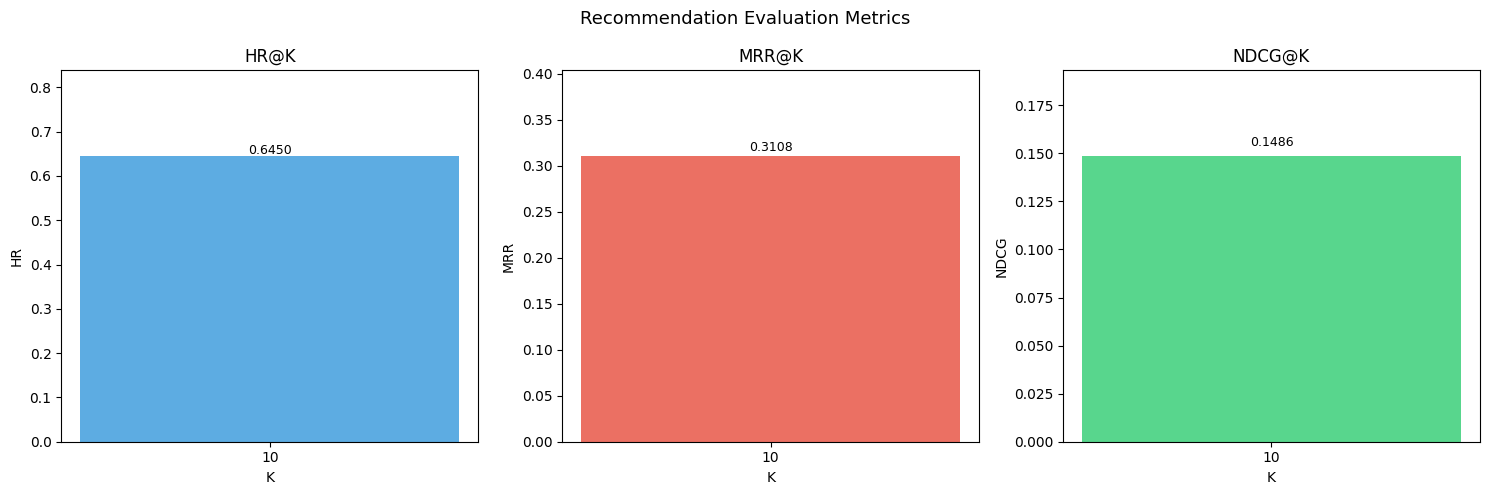

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_names = ["HR", "MRR", "NDCG"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for ax, name, color in zip(axes, metric_names, colors):
    values = [ranking_metrics[k][name] for k in K_VALUES]
    ax.bar([str(k) for k in K_VALUES], values, color=color, alpha=0.8)
    ax.set_title(f"{name}@K")
    ax.set_xlabel("K")
    ax.set_ylabel(name)
    ax.set_ylim(0, max(values) * 1.3 if max(values) > 0 else 1.0)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Recommendation Evaluation Metrics", fontsize=13)
plt.tight_layout()
plt.show()


In [20]:
# Coverage
all_recommended = set()
for res in results:
    all_recommended.update(res["top_k_recs"][:MAX_K])
coverage = len(all_recommended) / len(movie_titles_set)
print(f"Coverage@{MAX_K}: {coverage:.4f} ({len(all_recommended)}/{len(movie_titles_set)} unique movies)")

def intra_list_diversity(ranked_list):
    if len(ranked_list) < 2:
        return 0.0
    genre_sets = []
    for movie in ranked_list:
        genres = adj.get(movie, {}).get("hasGenre", set())
        genre_sets.append(genres)
    distances = []
    for i in range(len(genre_sets)):
        for j in range(i + 1, len(genre_sets)):
            union = genre_sets[i] | genre_sets[j]
            inter = genre_sets[i] & genre_sets[j]
            distances.append(1.0 - len(inter) / len(union) if union else 1.0)
    return np.mean(distances) if distances else 0.0

diversities = [intra_list_diversity(res["top_k_recs"][:MAX_K]) for res in results]
avg_diversity = np.mean(diversities)
print(f"Avg Intra-List Diversity@{MAX_K}: {avg_diversity:.4f}")

# Novelty
item_popularity = {}
for movie in movie_titles_set:
    item_popularity[movie] = len(adj.get(movie, {}).get("rev_likes", set()))
max_popularity = max(item_popularity.values()) if item_popularity else 1

def novelty_score(ranked_list):
    if not ranked_list:
        return 0.0
    return np.mean([1.0 - item_popularity.get(m, 0) / max(max_popularity, 1) for m in ranked_list])

novelties = [novelty_score(res["top_k_recs"][:MAX_K]) for res in results]
avg_novelty = np.mean(novelties)
print(f"Avg Novelty@{MAX_K}: {avg_novelty:.4f}")

# Pattern distribution
pattern_counter = Counter()
for res in results:
    for pt in res.get("pattern_types", []):
        pattern_counter[pt] += 1
total_pats = sum(pattern_counter.values())
print(f"\nRecommendation Pattern Distribution:")
for pat, cnt in pattern_counter.most_common():
    print(f"  {pat}: {cnt} ({cnt/total_pats*100:.1f}%)")


# Path-type concentration summary
try:
    print_path_diversity_report(results, k=MAX_K, label=f"Path-balanced λ={LAMBDA_PATH_BALANCE}")
except NameError:
    summary = path_diversity_summary(results, k=MAX_K)
    print("Dominant path type:", summary["dominant_type"])
    print("Dominant path ratio:", round(summary["dominant_ratio"], 4))
    print("Path entropy:", round(summary["entropy"], 4))


Coverage@10: 0.1267 (91/718 unique movies)
Avg Intra-List Diversity@10: 0.8042
Avg Novelty@10: 0.2383

Recommendation Pattern Distribution:
  director: 4083 (40.8%)
  cast: 2794 (27.9%)
  genre: 1581 (15.8%)
  writer: 1541 (15.4%)
  cf: 1 (0.0%)

──────────────────────────────────────────────────
Path-Type Diversity — Path-balanced λ=0.0 @ K=10
──────────────────────────────────────────────────
  Total explanations : 10000
  Dominant type      : director
  Dominant ratio     : 0.4083
  Path entropy       : 1.3027

  Distribution:
    director       4083 ( 40.8%)
    cast           2794 ( 27.9%)
    genre          1581 ( 15.8%)
    writer         1541 ( 15.4%)
    cf                1 (  0.0%)


In [21]:
user_gender_map = build_user_gender_map(users_sub)
n_m = sum(1 for g in user_gender_map.values() if g == "M")
n_f = sum(1 for g in user_gender_map.values() if g == "F")
print(f"Gender map: {n_m} Male, {n_f} Female users")

group_metrics = compute_group_metrics(results, user_gender_map, K_VALUES)

print(f"\n{'K':>4} | {'HR_M':>7} | {'HR_F':>7} | {'MRR_M':>7} | {'MRR_F':>7} | {'NDCG_M':>8} | {'NDCG_F':>8}")
print("-" * 65)
for k in K_VALUES:
    gm = group_metrics["M"][k]
    gf = group_metrics["F"][k]
    print(f"{k:>4} | {gm['HR']:>7.4f} | {gf['HR']:>7.4f} | "
          f"{gm['MRR']:>7.4f} | {gf['MRR']:>7.4f} | "
          f"{gm['NDCG']:>8.4f} | {gf['NDCG']:>8.4f}")


Gender map: 500 Male, 500 Female users

   K |    HR_M |    HR_F |   MRR_M |   MRR_F |   NDCG_M |   NDCG_F
-----------------------------------------------------------------
  10 |  0.7340 |  0.5560 |  0.3571 |  0.2644 |   0.1806 |   0.1166


In [22]:
# Coverage rate: % of test users who received >= 1 recommendation
users_with_recs = sum(1 for r in results if len(r['top_k_recs']) > 0)
users_no_recs   = sum(1 for r in results if len(r['top_k_recs']) == 0)
print(f'Coverage rate:    {users_with_recs}/{len(results)} users '
      f'({users_with_recs/len(results):.1%}) received recommendations')
print(f'No-rec users:     {users_no_recs} '
      f'({users_no_recs/len(results):.1%}) got empty lists')

# Per-gender coverage
for g in ('M', 'F'):
    g_results = [r for r in results if user_gender_map.get(r['user']) == g]
    g_covered = sum(1 for r in g_results if len(r['top_k_recs']) > 0)
    if g_results:
        print(f'  {g}: {g_covered}/{len(g_results)} '
              f'({g_covered/len(g_results):.1%})')


Coverage rate:    1000/1000 users (100.0%) received recommendations
No-rec users:     0 (0.0%) got empty lists
  M: 500/500 (100.0%)
  F: 500/500 (100.0%)


In [23]:
from metrics import evaluate_ranking_sampled_group

sampled_group = evaluate_ranking_sampled_group(
    results, list(movie_titles_set), adj, user_gender_map,
    k_values=K_VALUES, n_negatives=99, seed=42
)

print(f"{'K':>4} | {'HR_M':>8} | {'HR_F':>8} | {'NDCG_M':>8} | {'NDCG_F':>8} | {'Gap NDCG':>9}")
print("-" * 60)
for k in K_VALUES:
    hr_m   = group_metrics["M"][k]["HR"]
    hr_f   = group_metrics["F"][k]["HR"]
    ndcg_m = sampled_group["M"][k]["NDCG"]
    ndcg_f = sampled_group["F"][k]["NDCG"]
    print(f"{k:>4} | {hr_m:>8.4f} | {hr_f:>8.4f} | "
          f"{ndcg_m:>8.4f} | {ndcg_f:>8.4f} | {ndcg_f-ndcg_m:>+9.4f}")


   K |     HR_M |     HR_F |   NDCG_M |   NDCG_F |  Gap NDCG
------------------------------------------------------------
  10 |   0.7340 |   0.5560 |   0.6277 |   0.6370 |   +0.0094


In [24]:
ilap = compute_all_ilap_metrics(results, user_gender_map, k=10, disadv="F", adv="M")
print_ilap_report(ilap, k=10, label="GPT-2 Path Model")


──────────────────────────────────────────────────
ILAP Fairness Metrics — GPT-2 Path Model @ K=10
──────────────────────────────────────────────────
  Differential Fairness ε               1.0136  (lower = fairer)
  Value Unfairness                      0.0292  (≈0 = fair)
  Absolute Unfairness                   0.0248  (≈0 = fair)
  Underestimation Unfairness            0.0201  (≈0 = fair)
  Overestimation Unfairness             0.0091  (≈0 = fair)
  NonParity Unfairness                  0.0173  (≈0 = fair)
  KS Statistic                          0.1880  (p=0.000)
  Generalized Cross Entropy            -0.0096  (lower = fairer)


In [25]:
from metrics import compute_path_fairness_metrics, print_path_fairness_report

path_fairness = print_path_fairness_report(
    results, user_gender_map,
    label="APEX",
    k=10,
)



──────────────────────────────────────────────────────────────
  Path-Level Fairness — Fu et al. SIGIR 2020 @ K=10
  Reference: Fairness-Aware Explainable Rec. over KGs
──────────────────────────────────────────────────────────────

  Simpson's Index of Diversity (SID) — explanation diversity:
    M (advantaged) : 0.6737
    F (disadvantaged): 0.6947
    Gap                : -0.0210

  HR@10 by group:
    M (advantaged) : 0.7340
    F (disadvantaged): 0.5560
    Gap                : +0.1780

  Metric      Value  Description
  --------------------------------------------------------
  GRU        0.1780  Group Recommendation Unfairness (lower=fairer)
  GEDU       0.0210  Group Explanation Diversity Unfairness (lower=fairer)
  IRU        0.3550  Individual Rec. Unfairness/Gini (lower=fairer)
  IEDU       0.0809  Individual Explanation Diversity Unfairness (lower=fairer)

──────────────────────────────────────────────────────────────



In [27]:
K_R = 10
cf_score, _ = counterfactual_fairness_score(results, user_gender_map, adj, K_R)
dp     = demographic_parity(results, user_gender_map, K_R)
hr_m   = group_metrics["M"][K_R]["HR"]
hr_f   = group_metrics["F"][K_R]["HR"]

print("=" * 60)
print("APEX — Comprehensive Report")
print("=" * 60)
print(f"\n-- Accuracy --")
for k in K_VALUES:
    print(f"  HR@{k}   = {ranking_metrics[k]['HR']:.4f}  (full catalog)")
    print(f"  MRR@{k}  = {sampled_metrics[k]['MRR']:.4f}  (sampled 1+99)")
    print(f"  NDCG@{k} = {sampled_metrics[k]['NDCG']:.4f}  (sampled 1+99)")
print(f"\n-- Gender Fairness --")
print(f"  HR_M@{K_R} = {hr_m:.4f}")
print(f"  HR_F@{K_R} = {hr_f:.4f}")
print(f"  Gap       = {hr_f - hr_m:+.4f}")
print(f"  DP@{K_R}   = {dp:.4f}")
print(f"  CF@{K_R}   = {cf_score:.4f}")


APEX — Comprehensive Report

-- Accuracy --
  HR@10   = 0.6450  (full catalog)
  MRR@10  = 0.5080  (sampled 1+99)
  NDCG@10 = 0.6313  (sampled 1+99)

-- Gender Fairness --
  HR_M@10 = 0.7340
  HR_F@10 = 0.5560
  Gap       = -0.1780
  DP@10   = 0.6154
  CF@10   = 0.3745


## 19. Multi-Run Statistical Validation

In [28]:
# import importlib
# import scripts.multi_run as multi_run
# importlib.reload(multi_run)
#
# SEEDS = [42, 123, 456]
#
# # Multi-run for our main model (demographic-blind GPT-2)
# our_runs = multi_run.run(
#     adj, all_users, test_set_dict, movie_titles_set,
#     user_gender_map, BASE_RELS, device,
#     paths_per_user=100, k_values=K_VALUES, seeds=SEEDS,
# )

In [29]:
# multi_run.report(our_runs, k_values=K_VALUES)